## Movies Dataset 2024 - Grupo 9
<hr style="border:1px solid gray">

# 1. Configuración inicial

## 1.1 Correr con UV

```shell
uv sync
uv run jupyter lab
```

## 1.2 Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import kagglehub
from scipy import stats as st
from scipy.stats import describe
from pathlib import Path
import shutil

## 1.3 Importart dataset

In [2]:
# Create data directory if it doesn't exist
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

# Download dataset (latest version by default)
download_path = kagglehub.dataset_download("asaniczka/tmdb-movies-dataset-2023-930k-movies")

# Copy to local data directory
csv_file = next(Path(download_path).glob("*.csv"))
local_path = data_dir / csv_file.name
shutil.copy2(csv_file, local_path)

print(f"Dataset copied to: {local_path}")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 238M/238M [00:42<00:00, 5.83MB/s]

Extracting files...


Dataset copied to: data/TMDB_movie_dataset_v11.csv


## 1.4 Carga del dataset

In [3]:
# Cargamos el dataset desde el directorio local de datos
data_path = "data/TMDB_movie_dataset_v11.csv"
movies = pd.read_csv(data_path)

# 2. Descripción del dataset IMDB Movies 2024


| Variable              | Descripción                                                                                  |
|-----------------------|----------------------------------------------------------------------------------------------|
| `id`                  | Unique identifier for each movie. (type: int)                                                |
| `title`               | Title of the movie (usually in English or the display title). (type: str)                    |
| `vote_average`        | Average vote or rating given by viewers (typically 0–10 scale). (type: float)                |
| `vote_count`          | Total count of votes received for the movie. (type: int)                                     |
| `status`              | Current status of the movie (Released, Rumored, Post Production, etc.). (type: str)          |
| `release_date`        | Date when the movie was released (format usually YYYY-MM-DD). (type: str)                    |
| `revenue`             | Total revenue generated by the movie (in USD; 0 often means unknown/missing). (type: int)    |
| `runtime`             | Duration of the movie in minutes (0 usually means unknown). (type: int)                      |
| `adult`               | Indicates if the movie is only for adult audiences (true/false). (type: bool)                |
| `backdrop_path`       | Relative path to the backdrop image for the movie . (type: str)                              |
| `budget`              | Estimated production budget of the movie (USD; 0 often means unknown/missing). (type: int64) |
| `homepage`            | Official website URL of the movie (empty string or null if not available). (type: str)       |
| `imdb_id`             | IMDb identifier for the movie (format: tt followed by 7–8 digits). (type: str)               |
| `original_language`   | ISO 639-1 code of the original language of the movie (e.g., 'en', 'fr', 'es'). (type: str)   |
| `original_title`      | Original title of the movie (in its original language). (type: str)                          |
| `overview`            | Brief plot summary or synopsis of the movie. (type: str)                                     |
| `popularity`          | Popularity score assigned by TMDB (higher = more popular). (type: float64)                   |
| `poster_path`         | Relative path to the poster image for the movie (prepend https://image.tmdb.org) (type: str) |
| `tagline`             | Short marketing tagline or slogan of the movie (often empty). (type: str)                    |
| `genres`              | List of genres (usually as comma-separated string or JSON in some datasets). (type: str)     |
| `production_companies`| Name(s) of the main production company/companies (often comma-separated or JSON) (type: str) |
| `production_countries`| Country/countries where the movie was produced (often comma-separated or JSON). (type: str)  |
| `spoken_languages`    | Language(s) spoken in the movie (comma-separated or JSON. ISO codes and names). (type: str)  |
| `keywords`            | Descriptive keywords/tags linked with the movie (often comma-separated or JSON). (type: str) |

# 3. Primera inspección

## 3.1 Dimensiones del dataset original

In [4]:
print(f"Dimensiones del dataset original: {movies.shape}")
# exclude columns w/o valuable data (e.g. backdrop_path, imdb_id,..)
columns = ['title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'budget', 'original_language', 'popularity', 'genres', 'production_companies', 'production_countries', 'keywords']
movies[columns].head()

Dimensiones del dataset original: (1386763, 24)


,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,budget,original_language,popularity,genres,production_companies,production_countries,keywords
0,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,160000000,en,83.952,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","rescue, mission, dream, airplane, paris, franc..."
1,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,165000000,en,140.241,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America","rescue, future, spacecraft, race against time,..."
2,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,185000000,en,130.643,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","joker, sadism, chaos, secret identity, crime f..."
3,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,237000000,en,79.932,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","future, society, culture clash, space travel, ..."
4,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,220000000,en,98.082,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"new york city, superhero, shield, based on com..."


In [5]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 1386763 entries, 0 to 1386762
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1386763 non-null  int64  
 1   title                 1386745 non-null  str    
 2   vote_average          1386763 non-null  float64
 3   vote_count            1386763 non-null  int64  
 4   status                1386763 non-null  str    
 5   release_date          1087689 non-null  str    
 6   revenue               1386763 non-null  int64  
 7   runtime               1386763 non-null  int64  
 8   adult                 1386763 non-null  bool   
 9   backdrop_path         347051 non-null   str    
 10  budget                1386763 non-null  int64  
 11  homepage              143036 non-null   str    
 12  imdb_id               661126 non-null   str    
 13  original_language     1386763 non-null  str    
 14  original_title        1386745 non-null  str  

In [6]:
movies[columns].describe()

,vote_average,vote_count,revenue,runtime,budget,popularity
count,1.386763e+06,1.386763e+06,1.386763e+06,1.386763e+06,1.386763e+06,1.386763e+06
mean,1.586379e+00,1.547256e+01,6.250065e+05,4.434268e+01,2.393964e+05,1.034636e+00
std,2.875701e+00,2.884502e+02,1.922113e+07,6.077080e+01,5.100747e+06,6.883404e+00
min,0.000000e+00,0.000000e+00,-1.200000e+01,-2.800000e+01,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e-01
50%,0.000000e+00,0.000000e+00,0.000000e+00,1.600000e+01,0.000000e+00,6.000000e-01
75%,2.000000e+00,1.000000e+00,0.000000e+00,8.500000e+01,0.000000e+00,7.300000e-01
max,1.000000e+01,3.449500e+04,5.000000e+09,1.440000e+04,1.000000e+09,2.994357e+03


## 3.2 Análisis de las variables numéricas

#### Nota: hay columnas con muchos valores en 0
IMDB usa el 0 para representar "unknown", no el valor 0. Por eso usamos alternativamente las siguientes medidas para obtener resultados útiles:
- `field_valid = movies['field'][movies['field'] > 0]` # subset de valores mayores a 0
- `movies['field'].replace(0, np.nan).mode()` # reemplazar 0 por NaN

In [86]:
movies['budget'].median() # example w/o filtering 0s

np.float64(0.0)

In [87]:
budget_valid = movies['budget'][movies['budget'] > 0]
budget_valid.median() # iltering 0s

np.float64(3500.0)

In [89]:
movies['popularity'].mean() # example w/o filtering 0s

np.float64(1.0346357596379894)

In [90]:
movies['popularity'].replace(0, np.nan).mean() # example filtering 0s

np.float64(1.2380071615747437)

#### Definir sets válidos

In [94]:
budget_valid = movies['budget'][movies['budget'] > 0]
revenue_valid = movies['revenue'][movies['revenue'] != 0] # movie can also lose money
popularity_valid = movies['popularity'][movies['popularity'] > 0]
vote_count_valid = movies['vote_count'][movies['vote_count'] > 0]
vote_average_valid = movies['vote_average'][movies['vote_average'] > 0]
runtime_valid = movies['runtime'][movies['runtime'] > 0]

#### Max/Mins

In [95]:
# Maximum budget
max_budget = budget_valid.max()
print(f"Maximum budget: ${max_budget:,}")

# Minimum budget
min_budget = budget_valid.min()
print(f"Minimum budget: ${min_budget:,}")

# Maximum revenue
max_revenue = revenue_valid.max()
print(f"Maximum revenue: ${max_revenue:,}")

# Minimum revenue
min_revenue = revenue_valid.min()
print(f"Minimum revenue: ${min_revenue:,}")

# Maximum popularity
max_popularity = popularity_valid.replace(0, np.nan).max()
print(f"Maximum popularity: {max_popularity:,}")

# Minimum popularity
min_popularity = popularity_valid.replace(0, np.nan).min()
print(f"Minimum popularity: {min_popularity:,}")

# Maximum vote_average
max_vote_average = vote_average_valid.replace(0, np.nan).max()
print(f"Maximum vote_average: {max_vote_average:,}")

# Minimum vote_average
min_vote_average = vote_average_valid.replace(0, np.nan).min()
print(f"Minimum vote_average: {min_vote_average:,}")

# Maximum vote_count
max_vote_count = vote_count_valid.replace(0, np.nan).max()
print(f"Maximum vote_count: {max_vote_count:,}")

# Minimum vote_count
min_vote_count = vote_count_valid.replace(0, np.nan).min()
print(f"Minimum vote_count: {min_vote_count:,}")

# Maximum runtime
max_runtime = runtime_valid.replace(0, np.nan).max()
print(f"Maximum runtime: {max_runtime:,}")

# Minimum vote_count
min_runtime = runtime_valid.replace(0, np.nan).min()
print(f"Minimum runtime: {min_runtime:,}")

Maximum budget: $999,999,999
Minimum budget: $1
Maximum revenue: $4,999,999,999
Minimum revenue: $-12
Maximum popularity: 2,994.357
Minimum popularity: 0.0071
Maximum vote_average: 10.0
Minimum vote_average: 0.5
Maximum vote_count: 34,495
Minimum vote_count: 1
Maximum runtime: 14,400
Minimum runtime: 1


## 3.3 Histogramas

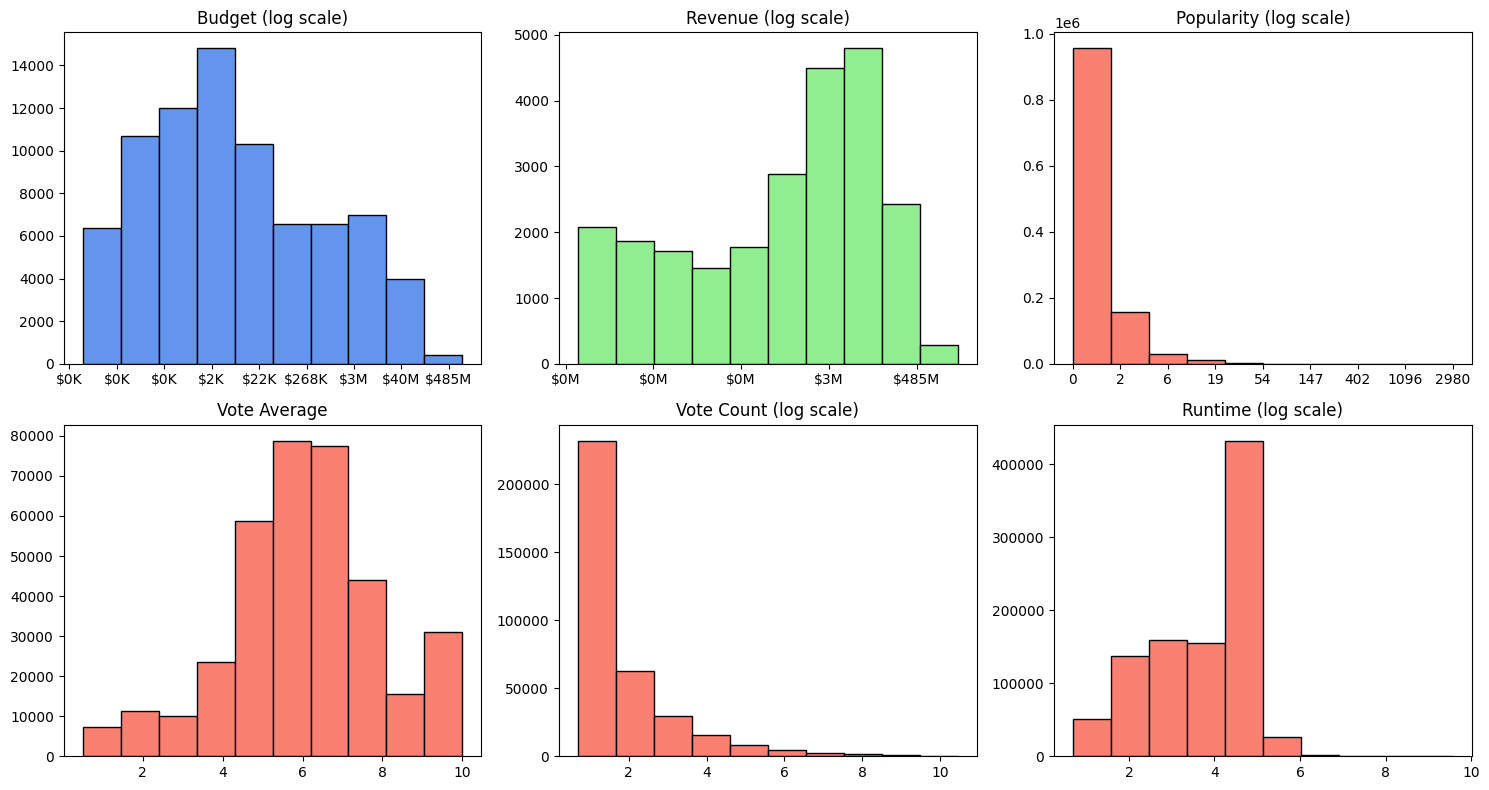

In [134]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))

# --- Budget ---
ax[0,0].hist(np.log1p(budget_valid), bins=10, color='cornflowerblue', edgecolor='black')
ax[0,0].set_title('Budget (log scale)')

# Nice original-scale tick labels
def log1p_inverse(y):
    return np.expm1(y)

ax[0,0].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda y, pos: f"${log1p_inverse(y)/1e6:.0f}M" if y >= 13 else f"${log1p_inverse(y)/1e3:.0f}K"
))

# --- Revenue ---
# valid_revenue = movies['revenue'][movies['revenue'] > 0]  # also drop negative
ax[0,1].hist(np.log1p(revenue_valid), bins=10, color='lightgreen', edgecolor='black')
ax[0,1].set_title('Revenue (log scale)')
ax[0,1].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda y, pos: f"${log1p_inverse(y)/1e6:.0f}M"
))

# --- Popularity ---
ax[0,2].hist(np.log1p(popularity_valid), bins=10, color='salmon', edgecolor='black')
ax[0,2].set_title('Popularity (log scale)')
ax[0,2].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda y, pos: f"{log1p_inverse(y):.0f}"
))

# --- Vote Average ---
ax[1,0].hist(vote_average_valid, bins=10, color='salmon', edgecolor='black')
ax[1,0].set_title('Vote Average')

# --- Vote Count ---
ax[1,1].hist(np.log1p(vote_count_valid), bins=10, color='salmon', edgecolor='black')
ax[1,1].set_title('Vote Count (log scale)')

# --- Rubntime ---
ax[1,2].hist(np.log1p(runtime_valid), bins=10, color='salmon', edgecolor='black')
ax[1,2].set_title('Runtime (log scale)')

plt.tight_layout()
plt.show()

### Movies per month
<hr style="border:1px solid gray">


Standarize dates:

In [100]:
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')

Visualize:

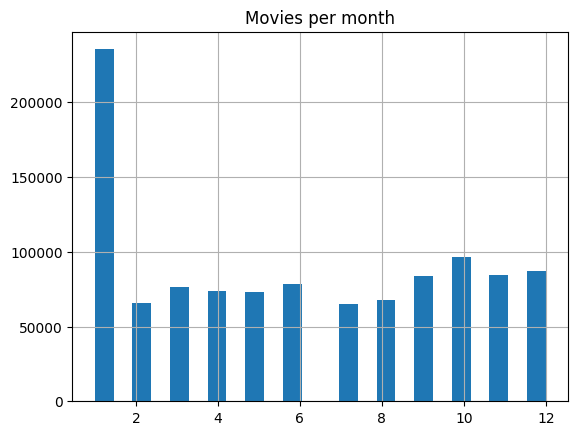

In [101]:
movies['release_month'] = movies['release_date'].dt.month
ax = movies['release_month'].hist(bins=24)
ax.set_title('Movies per month')
plt.show()

### 1. Medidas de tendencia central: media, mediana y moda
<hr style="border:1px solid gray">


#### Media

In [102]:
np.mean(budget_valid.replace(0, np.nan))    # Budget

np.float64(4220735.033691009)

In [103]:
np.mean(revenue_valid.replace(0, np.nan)) # Revenue

np.float64(36411354.11283818)

In [104]:
np.mean(popularity_valid) # Popularity

np.float64(1.2380071615747437)

In [105]:
np.mean(vote_count_valid.replace(0, np.nan)) # Vote count

np.float64(59.95589533805005)

In [106]:
np.mean(vote_average_valid.replace(0, np.nan)) # Vote average

np.float64(6.152002077763734)

In [107]:
np.mean(runtime_valid.replace(0, np.nan)) # Runtime

np.float64(63.89840318469418)

#### Mediana

In [108]:
np.median(budget_valid.replace(0, np.nan))  # Budget

np.float64(3500.0)

In [109]:
np.median(revenue_valid) # Revenue

np.float64(940000.0)

In [110]:
np.median(popularity_valid) # Popularity

np.float64(0.6)

In [111]:
np.median(vote_count_valid) # Vote count

np.float64(2.0)

In [112]:
np.median(vote_average_valid) # Vote average

np.float64(6.0)

In [113]:
np.median(runtime_valid) # Runtime

np.float64(62.0)

#### Moda

In [114]:
budget_valid.mode()[0]     # Budget

np.int64(100)

In [116]:
revenue_valid.mode()[0]     # Revenue

np.int64(1)

In [117]:
popularity_valid.mode()[0]     # Popularity

np.float64(0.6)

In [118]:
vote_count_valid.mode()[0]     # Vote count

np.int64(1)

In [119]:
vote_average_valid.mode()[0]     # Vote average

np.float64(6.0)

In [120]:
runtime_valid.mode()[0]     # Runtime

np.int64(90)

# 4. Análisis de inconsistencias

## 4.1 Películas duplicadas

In [26]:
# Dataset information
print(f"Amount of movies (rows): {len(movies)}")
print(f"Amount of unique movies: {movies['id'].nunique()}")
print(f"Amount of columns: {len(movies.columns)}")

# Check for duplicate IDs
duplicate_ids = movies['id'].duplicated().sum()
if duplicate_ids > 0:
    print(f"\n Found {duplicate_ids} duplicate movie IDs!")
else:
    print("\nAll movie IDs are unique")

Amount of movies (rows): 1386763
Amount of unique movies: 1385558
Amount of columns: 24

 Found 1205 duplicate movie IDs!


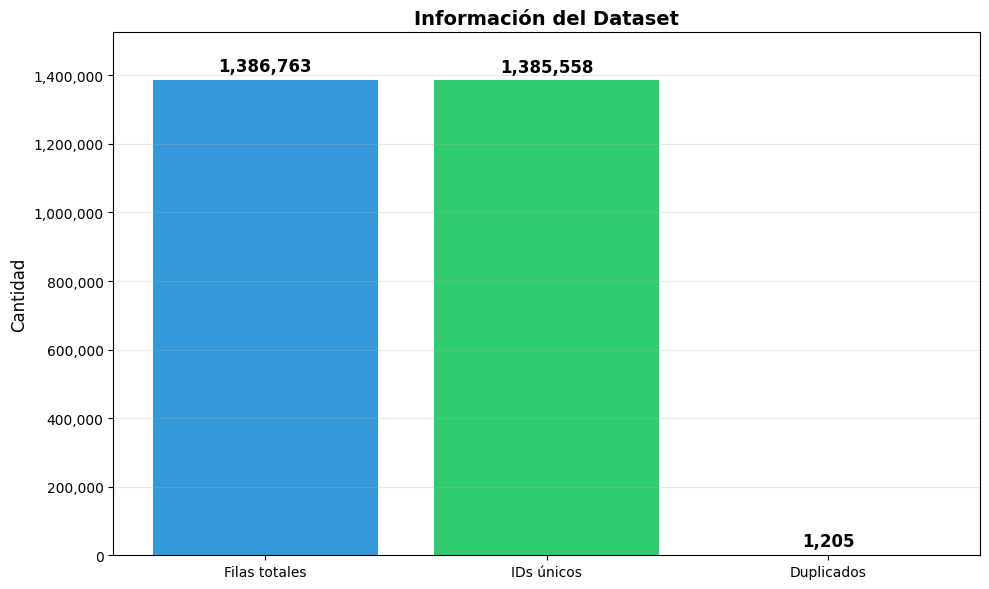

In [27]:
# Visualizar información del dataset
fig, ax = plt.subplots(figsize=(10, 6))

# Datos
categorias = ['Filas totales', 'IDs únicos', 'Duplicados']
valores = [len(movies), movies['id'].nunique(), len(movies) - movies['id'].nunique()]
colores = ['#3498db', '#2ecc71', '#e74c3c']

# Crear gráfico de barras
bars = ax.bar(categorias, valores, color=colores)

# Configurar etiquetas y título
ax.set_title('Información del Dataset', fontsize=14, fontweight='bold')
ax.set_ylabel('Cantidad', fontsize=12)

# Formatear el eje Y para mostrar valores completos
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Ajustar escala del eje Y
max_val = max(valores)
ax.set_ylim(0, max_val * 1.1)

# Agregar valores sobre las barras
for bar, valor in zip(bars, valores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + max_val * 0.01,
             f'{valor:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Agregar grid para mejor lectura
ax.grid(axis='y', alpha=0.3)

# Rotar etiquetas si es necesario
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()